**Overall Purpose**

The code fine-tunes a pre-trained Geneformer model to classify pancreatic cell types from single-cell RNA-seq data that has been tokenized into gene sequences.

Key Sections:

**1. Setup & Environment**

Installs dependencies (scanpy, datasets, etc.)

Clones Geneformer repository

Sets up CUDA memory configuration

Mounts Google Drive for data access

**2. Data Loading & Exploration**

Loads tokenized pancreatic dataset

```
pancreas_dataset = "/content/drive/My Drive/geneformer_test2/pancreas_scib.dataset"
token_dataset = load_from_disk(pancreas_dataset)
```

Data contains input_ids (tokenized genes), celltype, and other metadata

Explores cell type distribution with visualizations

**3. Data Preprocessing Pipeline**

Filter rare cell types (>10% threshold)

```
clusters_to_keep = [k for k, v in celltype_counter.items() if v > min_cells]

# Keep only full-length sequences (2048 tokens)
filtered_data = filtered_data.filter(lambda x: x["length"] == 2048, num_proc=16)

# Downsample to 1000 cells to avoid memory issues
target_total = 1000
```

**4. Memory Management**

Aggressive downsampling (1000 cells) to prevent CUDA OOM

Uses proportional sampling to maintain cell type ratios

Implements gradient checkpointing and other memory optimizations

**5. Label Preparation**

Create numerical labels for training

target_names = sorted(list(set(train_data["label"])))

celltype_label_dict = {name: idx for idx, name in enumerate(target_names)}

**6. Model Training**

Load pre-trained Geneformer

```
model = BertForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=len(celltype_label_dict.keys()),
    output_attentions=False,
    output_hidden_states=False
).to("cuda")

```

**7. Training Configuration**

Uses conservative settings to avoid memory issues

Implements gradient accumulation and checkpointing

Includes comprehensive evaluation metrics

**Key Features:**

*Memory Optimization:*

Dataset downsampling (1000 cells)

Gradient checkpointing enabled

Batch size = 5 with gradient accumulation

Sequence length capped at 2048

*Data Quality:*

Filters rare cell types (>10% threshold)

Only uses full-length sequences

Maintains proportional cell type distribution

*Biological Relevance:*

Focuses on pancreatic islet cells (beta, alpha, delta, etc.)

Includes cell type distribution analysis

Provides biological context for each cell type

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!pip install numpy==1.26.4
import os

In [ ]:
!pip install scanpy
!pip install loompy
!pip install datasets

In [ ]:
!git lfs install
!git clone https://huggingface.co/ctheodoris/Geneformer
!ls -1

Git LFS initialized.
fatal: destination path 'Geneformer' already exists and is not an empty directory.
drive
Geneformer
pancreas_output
pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset
sample_data
wandb


In [ ]:
%cd Geneformer
!pip install -e .

/content/Geneformer
Obtaining file:///content/Geneformer
  Preparing metadata (setup.py) ... done
  Attempting uninstall: geneformer
    Found existing installation: geneformer 0.1.0
    Uninstalling geneformer-0.1.0:
      Successfully uninstalled geneformer-0.1.0
  Running setup.py develop for geneformer


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import datetime
import glob
import pickle
import subprocess

import numpy as np
import pandas as pd
import seaborn as sns

from collections import Counter, defaultdict

from datasets import Dataset, DatasetDict, load_from_disk

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

from transformers import BertForSequenceClassification, Trainer
from transformers.training_args import TrainingArguments

from geneformer import Classifier, DataCollatorForCellClassification, EmbExtractor

***Set up environment variables***

In [ ]:
import torch
import gc

# Clear GPU cache
torch.cuda.empty_cache()
gc.collect()

# Check GPU memory
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB


In [ ]:
import torch
torch.cuda.empty_cache()
print(f"CUDA memory after empty_cache: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")

CUDA memory after empty_cache: 0.00 GB


https://geneformer.readthedocs.io/en/latest/geneformer.classifier.html

**prepare_data**

Prepare data for cell state or gene classification.

Parameters

**input_data_filePath**

Path to directory containing .dataset input

**output_directoryPath**

Path to directory where prepared data will be saved

**output_prefixstr**

Prefix for output file

**split_id_dict : None, dict**

Dictionary of IDs for train and test splits

Three-item dictionary with keys: attr_key, train, test

**attr_key:** key specifying name of column in .dataset that contains the IDs for the data splits

**train:** list of IDs in the attr_key column to include in the train split

**test:** list of IDs in the attr_key column to include in the test split

For example:

{“attr_key”: “individual”, “train”: [“patient1”, “patient2”, “patient3”, “patient4”], “test”: [“patient5”, “patient6”]}

**test_size : None, float**

Proportion of data to be saved separately and held out for test set
(e.g. 0.2 if intending hold out 20%)

If None, will inherit from split_sizes[“test”] from Classifier

The training set will be further split to train / validation in self.validate
Note: only available for CellClassifiers

**attr_to_split:** None, str

Key for attribute on which to split data while balancing potential confounders
e.g. “patient_id” for splitting by patient while balancing other characteristics
Note: only available for CellClassifiers

**attr_to_balance:** None, list

List of attribute keys on which to balance data while splitting on attr_to_split
e.g. [“age”, “sex”] for balancing these characteristics while splitting by patient

Note: only available for CellClassifiers

**max_trials** : None, int

Maximum number of trials of random splitting to try to achieve balanced other attributes.

https://geneformer.readthedocs.io/en/latest/geneformer.classifier.html

**Geneformer classifier.**

**Cell state classifier:**

Single-cell transcriptomes as Geneformer rank value encodings with cell state labels in Geneformer .dataset format (generated from single-cell RNAseq data by tokenizer.py)

**Gene classifier:**

Dictionary in format {Gene_label: list(genes)} for gene labels and single-cell transcriptomes as Geneformer rank value encodings in Geneformer .dataset format (generated from single-cell RNAseq data by tokenizer.py)

**Geneformer classifier.**


Parameters:


**classifier{“cell”, “gene”}**

Whether to fine-tune a cell state or gene classifier.

**quantize : bool, dict**

**cell_state_dict: None, dict**

Cell states to fine-tune model to distinguish.

Two-item dictionary with keys: state_key and states

**state_key:** key specifying name of column in .dataset that defines the states to model

**states:** list of values in the state_key column that specifies the states to model

Alternatively, instead of a list of states, can specify “all” to use all states in that state key from input data.

Of note, if using “all”, states will be defined after data is filtered.

Must have at least 2 states to model.

For example:

{“state_key”: “disease”,
“states”: [“nf”, “hcm”, “dcm”]}

or

{“state_key”: “disease”,
“states”: “all”}

**gene_class_dict:** None, dict

Gene classes to fine-tune model to distinguish.

Dictionary in format:

{Gene_label_A: list(geneA1, geneA2, …),

Gene_label_B: list(geneB1, geneB2, …)}

Gene values should be Ensembl IDs.

**filter_data** : None, dict

Default is to fine-tune with all input data.
Otherwise, dictionary specifying .dataset column name and list of values to filter by.

**rare_threshold** : float

Threshold below which rare cell states should be removed.
For example, setting to 0.05 will remove cell states representing
< 5% of the total cells from the cell state classifier’s possible classes.

**max_ncells** : None, int

Maximum number of cells to use for fine-tuning.

Default is to fine-tune with all input data.

**max_ncells_per_class** : None, int

Maximum number of cells per cell class to use for fine-tuning.
Of note, will be applied after max_ncells above.
(Only valid for cell classification.)

**training_args: None, dict

Training arguments for fine-tuning.
If None, defaults will be inferred for 6 layer Geneformer.

Note: Hyperparameter tuning is highly recommended, rather than using defaults.

**freeze_layers** : int

Number of layers to freeze from fine-tuning.

0: no layers will be frozen;

2: first two layers will be frozen; etc.

num_crossval_splits{0, 1, 5}

0: train on all data without splitting

1: split data into train and eval sets by designated split_sizes[“valid”]

5: split data into 5 folds of train and eval sets by designated split_sizes[“valid”]

**split_sizes** : None, dict

Dictionary of proportion of data to hold out for train, validation, and test sets
{“train”: 0.8, “valid”: 0.1, “test”: 0.1} if intending 80/10/10 train/valid/test split

**stratify_splits_col** : None, str

Name of column in .dataset to be used for stratified splitting.
Proportion of each class in this column will be the same in the splits as in the original dataset.

**no_eval** : bool
If True, will skip eval step and use all data for training.
Otherwise, will perform eval during training.

**forward_batch_sizeint**
Batch size for forward pass (for evaluation, not training).

**model_version : str

To auto-select settings for model version other than current default.

Current options:

V1: models pretrained on ~30M cells,

V2: models pretrained on ~104M cells

**token_dictionary_file** : None, str

Default is to use token dictionary file from Geneformer
Otherwise, will load custom gene token dictionary.

**🔧 Hyperparameters :**

**max_input_size = 2048**

Maximum number of tokens (genes) per cell input.

If a cell expresses more than 2048 genes, it will be truncated; if fewer, it may be padded.

**geneformer_batch_size = 5**

Number of examples (cells) processed in one forward/backward pass.

A small batch size reduces memory usage but may make training slower or noisier.

**max_lr = 5e-5**

Maximum learning rate (i.e., 0.00005).

Controls the step size during optimization. Too high can overshoot; too low may converge slowly.

**lr_schedule_fn = "linear"**

Learning rate schedule. "linear" means the learning rate will decay linearly from max_lr to 0 across training steps.

Helps the model stabilize after initial updates.

**warmup_steps = 500**

Number of steps over which the learning rate will increase linearly from 0 to max_lr.

Helps prevent sudden jumps at the beginning of training.

**epochs = 30**

Number of full passes through the training dataset.

More epochs mean more training time and potential overfitting if too high.

**optimizer = "adamw"**

Optimization algorithm. AdamW is a version of Adam that decouples weight decay from the gradient update.

Well-suited for transformer-based models.

**freeze_layers = 0**

Number of transformer layers to "freeze" (not update during training).

If set > 0, the first freeze_layers will be frozen; 0 means the full model is trainable

**🔍 What is TrainingArguments?**

TrainingArguments is a class provided by the Hugging Face transformers library. It defines all the parameters needed to train or evaluate a model using the Trainer API.

```
training_args = {
    "learning_rate": 5e-5,
    "do_train": True,
    "do_eval": True,
    "eval_strategy": "epoch",
    "save_strategy": "epoch",
    "logging_steps": 100,
    "group_by_length": True,
    "length_column_name": "length",
    "disable_tqdm": False,
    "lr_scheduler_type": "linear",
    "warmup_steps": 500,
    "weight_decay": 0.01,
    "per_device_train_batch_size": 8,
    "per_device_eval_batch_size": 8,
    "num_train_epochs": 3,
    "load_best_model_at_end": True,

```


```
validate(model_directory, prepared_input_data_file, id_class_dict_file, output_directory, output_prefix, split_id_dict=None, attr_to_split=None, attr_to_balance=None, gene_balance=False, max_trials=100, pval_threshold=0.1, save_eval_output=True, predict_eval=True, predict_trainer=False, n_hyperopt_trials=0, save_gene_split_datasets=True, debug_gene_split_datasets=False)
```

**(Cross-)validate cell state or gene classifier.**

**Parameters**

**model_directoryPath**

Path to directory containing model

**prepared_input_data_filePath**

Path to directory containing _labeled.dataset previously prepared by Classifier.prepare_data

**id_class_dict_filePath**

Path to _id_class_dict.pkl previously prepared by Classifier.prepare_data
*(dictionary of format: numerical IDs: class_labels)*

**output_directoryPath**

Path to directory where model and eval data will be saved

**output_prefix**

Prefix for output files

**split_id_dict:** None, dict

Dictionary of IDs for train and eval splits

Three-item dictionary with keys: attr_key, train, eval

**attr_key:**

key specifying name of column in .dataset that contains the IDs for the data splits

**train:** list of IDs in the attr_key column to include in the train split

**eval:** list of IDs in the attr_key column to include in the eval split

For example:

{“attr_key”: “individual”,

“train”: [“patient1”, “patient2”, “patient3”, “patient4”],

“eval”: [“patient5”, “patient6”]}

Note: only available for CellClassifiers with 1-fold split (self.classifier=”cell”; self.num_crossval_splits=1)

**attr_to_split** : None, str

Key for attribute on which to split data while balancing potential confounders
e.g. “patient_id” for splitting by patient while balancing other characteristics

Note: only available for CellClassifiers with 1-fold split (self.classifier=”
cell”; self.num_crossval_splits=1)

**attr_to_balance** : None, list

List of attribute keys on which to balance data while splitting on attr_to_split
e.g. [“age”, “sex”] for balancing these characteristics while splitting by patient

**gene_balance** : None, bool

Whether to automatically balance genes in training set.
Only available for binary gene classifications.

**max_trials** : None, int

Maximum number of trials of random splitting to try to achieve balanced other attribute

If no split is found without significant (p < pval_threshold) differences in other attributes, will select best

**pval_threshold** : None, float

**save_eval_output** : bool

Whether to save cross-fold eval output
Saves as pickle file of dictionary of eval metrics

**predict_eval**: bool

Whether or not to save eval predictions

Saves as a pickle file of self.evaluate predictions

**predict_trainer**: bool

Whether or not to save eval predictions from trainer
Saves as a pickle file of trainer predictions

**n_hyperopt_trials** : int

Number of trials to run for hyperparameter optimization

If 0, will not optimize hyperparameters

**save_gene_split_dataset** : bool

Whether or not to save train, valid, and test gene-labeled datasets

In [ ]:
token_dictionary = "/content/Geneformer/geneformer/token_dictionary_gc104M.pkl"
model_v1 = "/content/Geneformer/Geneformer-V1-10M/"
model_v2 = "/content/Geneformer/Geneformer-V2-104M"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


If your dataset includes a column named "label" (like a duplicate of celltype), it conflicts with Geneformer's processing logic.

You need to rename or remove the "label" column from your dataset before calling cc.prepare_data().



In [ ]:
!cp -r "/content/drive/My Drive/geneformer_test2/pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset" /content/
!ls -l /content/pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset

total 43868
-rw-r--r-- 1 root root    16592 Jul 30 23:40 cache-9cb4f12706964ef0.arrow
-rw-r--r-- 1 root root 22452088 Jul 30 23:40 cache-f6d45f2ea2d2c03f.arrow
-rw------- 1 root root 22434416 Jul 30 23:59 data-00000-of-00001.arrow
-rw------- 1 root root      733 Jul 30 23:59 dataset_info.json
-rw------- 1 root root      372 Jul 30 23:59 state.json


In [ ]:
!ls -1 /content/

drive
Geneformer
pancreas_output
pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset
sample_data
wandb


🚀 Geneformer Pancreas Cell Type Classification

🔧 GPU Memory Management:
GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB
📁 Output: /content/pancreas_output/250730235941

📊 STEP 1: Loading and exploring dataset...
✅ Loaded 2000 cells

🏷️  Cell types (4 total):
  alpha: 815 (40.8%)
  beta: 619 (30.9%)
  ductal: 318 (15.9%)
  acinar: 248 (12.4%)

📋 Dataset structure:
  Columns: ['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length']
  Sample cell: alpha with 1078 tokens

📊 STEP 2: Creating data splits...
Splits: 70% train, 15% eval, 15% test

📊 Split sizes:
  train: 1400 cells
  eval: 300 cells
  test: 300 cells
✅ Saved dataset with splits

🔧 STEP 3: Setting up classifier...
✅ Classifier ready

📋 STEP 4: Preparing data for training...
✅ Data prepared

🚀 STEP 5: Training model...


  0%|          | 0/1 [00:00<?, ?it/s]

****** Validation split: 1/1 ******



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/Geneformer/Geneformer-V2-104M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: bogdan-tanasa (bogdan-tanasa-university-of-california) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/content/Geneformer/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}


...

  0%|          | 0/38 [00:00<?, ?it/s]

✅ Training completed!
❌ Training failed: Unknown format code 'f' for object of type 'str'

🧪 STEP 6: Evaluating model...
✅ Found model: /content/pancreas_output/250730235941/250730_geneformer_cellClassifier_pancreas_classifier/ksplit1


  0%|          | 0/38 [00:00<?, ?it/s]

✅ Evaluation completed!

📊 TEST RESULTS:
  macro_f1: 0.9444
  acc: 0.9567

📊 STEP 7: Creating simple visualizations...


<Figure size 1000x1000 with 0 Axes>

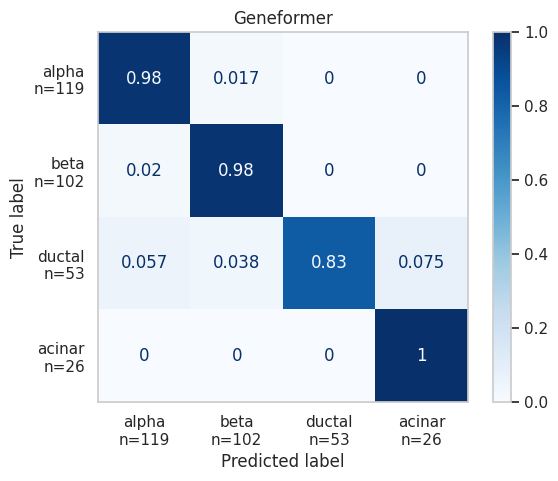

✅ Confusion matrix saved
❌ Predictions plot failed: [Errno 2] No such file or directory: '/content/pancreas_output/250730235941/pancreas_classifier_pred_dict.pkl'

📊 PERFORMANCE SUMMARY:
Accuracy: 0.9567
Macro F1-Score: 0.9444
✅ Simple summary saved to: /content/pancreas_output/250730235941/pancreas_classifier_simple_summary.txt

🎉 ANALYSIS COMPLETE!
📁 Output: /content/pancreas_output/250730235941

📊 Generated files:

📋 Data files (5):
  📄 pancreas_classifier_test_test_metrics_dict.pkl
  📄 pancreas_classifier_labeled_train.dataset
  📄 pancreas_classifier_id_class_dict.pkl
  📄 pancreas_classifier_labeled_test.dataset
  📄 pancreas_classifier_test_pred_dict.pkl

📈 Summary files (1):
  📊 pancreas_classifier_simple_summary.txt

🤖 Model files (2):
  🧠 pancreas_classifier_conf_mat.pdf
  🧠 250730_geneformer_cellClassifier_pancreas_classifier

📈 BEST PERFORMANCE:
  Accuracy: 0.9567
  F1-Score: 0.9444

✅ Done! Check /content/pancreas_output/250730235941 for results.


In [ ]:

"""
Simplified Geneformer Fine-Tuning for Pancreas Cell Type Classification
Clean, Fixed Implementation with Clear Logic
"""

import datetime
import os
import warnings
import numpy as np
import torch
import gc
from collections import Counter
from datasets import load_from_disk
from geneformer import Classifier

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# =============================================================================
# CONFIGURATION
# =============================================================================

# All parameters in one place - easy to modify
CONFIG = {
    # Paths
    "dataset_path": "/content/pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset",
    "model_path": "/content/Geneformer/Geneformer-V2-104M",
    "output_base_dir": "/content/pancreas_output",

    # Data splitting
    "train_ratio": 0.7,
    "eval_ratio": 0.15,
    "test_ratio": 0.15,
    "random_state": 42,

    # Training parameters
    "num_train_epochs": 0.9,
    "learning_rate": 0.0008,
    "lr_scheduler_type": "polynomial",
    "warmup_steps": 500,
    "weight_decay": 0.03,
    "per_device_train_batch_size": 8,
    "forward_batch_size": 8,
    "freeze_layers": 2,
    "nproc": 16,
    "ngpu": 1,

    # Cell type filtering (None = use all cell types)
    "filter_cell_types": None,  # or ["acinar", "alpha", "beta", "ductal"]

    # Plotting
    "plot_dpi": 300,
    "plot_figsize": (10, 8),
    "color_palette": "Set3"
}

# =============================================================================
# SETUP AND ENVIRONMENT
# =============================================================================

print("🚀 Geneformer Pancreas Cell Type Classification")
print("="*60)

# GPU memory management
print(f"\n🔧 GPU Memory Management:")
torch.cuda.empty_cache()
gc.collect()
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

# Setup output directory
current_date = datetime.datetime.now()
datestamp = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}{current_date.hour:02d}{current_date.minute:02d}{current_date.second:02d}"
output_dir = f"{CONFIG['output_base_dir']}/{datestamp}"
output_prefix = "pancreas_classifier"

os.makedirs(output_dir, exist_ok=True)
print(f"📁 Output: {output_dir}")

# =============================================================================
# STEP 1: LOAD AND EXPLORE DATASET
# =============================================================================

print(f"\n📊 STEP 1: Loading and exploring dataset...")

# Check if dataset exists
if not os.path.exists(CONFIG["dataset_path"]):
    print(f"❌ Dataset not found: {CONFIG['dataset_path']}")
    print("Please check the dataset path in CONFIG")
    exit()

# Load dataset
try:
    dataset = load_from_disk(CONFIG["dataset_path"])
    print(f"✅ Loaded {len(dataset)} cells")
except Exception as e:
    print(f"❌ Failed to load dataset: {e}")
    exit()

# Explore cell type distribution
celltype_counts = Counter([example['celltype'] for example in dataset])
print(f"\n🏷️  Cell types ({len(celltype_counts)} total):")
for celltype, count in celltype_counts.most_common():
    pct = 100 * count / len(dataset)
    print(f"  {celltype}: {count} ({pct:.1f}%)")

# Show dataset structure
print(f"\n📋 Dataset structure:")
print(f"  Columns: {list(dataset.features.keys())}")
print(f"  Sample cell: {dataset[0]['celltype']} with {len(dataset[0]['input_ids'])} tokens")

# =============================================================================
# STEP 2: CREATE DATA SPLITS
# =============================================================================

print(f"\n📊 STEP 2: Creating data splits...")

def create_simple_splits(dataset, train_ratio=0.7, eval_ratio=0.15, test_ratio=0.15, random_state=42):
    """
    Create simple train/eval/test splits using the datasets library
    This is the user's preferred simple split method
    """
    print(f"Splits: {train_ratio*100:.0f}% train, {eval_ratio*100:.0f}% eval, {test_ratio*100:.0f}% test")

    # Shuffle and split
    dataset = dataset.shuffle(seed=random_state)
    n_total = len(dataset)
    n_train = int(n_total * train_ratio)
    n_eval = int(n_total * eval_ratio)
    n_test = n_total - n_train - n_eval

    # Create split labels
    split_labels = ["train"] * n_train + ["eval"] * n_eval + ["test"] * n_test
    dataset = dataset.map(lambda example, idx: {"split": split_labels[idx]}, with_indices=True)

    return dataset, {
        'train_size': n_train,
        'eval_size': n_eval,
        'test_size': n_test,
        'total_size': n_total
    }

# Create splits
dataset, split_info = create_simple_splits(
    dataset,
    CONFIG["train_ratio"],
    CONFIG["eval_ratio"],
    CONFIG["test_ratio"],
    CONFIG["random_state"]
)

# Show split distribution
split_counts = Counter([example["split"] for example in dataset])
print(f"\n📊 Split sizes:")
for split, count in split_counts.items():
    print(f"  {split}: {count} cells")

# Save dataset with splits
complete_dataset_path = f"{output_dir}/pancreas_with_splits_ready.dataset"
dataset.save_to_disk(complete_dataset_path)
print(f"✅ Saved dataset with splits")

# =============================================================================
# STEP 3: SETUP CLASSIFIER
# =============================================================================

print(f"\n🔧 STEP 3: Setting up classifier...")

# Training arguments
training_args = {
    "num_train_epochs": CONFIG["num_train_epochs"],
    "learning_rate": CONFIG["learning_rate"],
    "lr_scheduler_type": CONFIG["lr_scheduler_type"],
    "warmup_steps": CONFIG["warmup_steps"],
    "weight_decay": CONFIG["weight_decay"],
    "per_device_train_batch_size": CONFIG["per_device_train_batch_size"],
    "seed": CONFIG["random_state"],
    "gradient_checkpointing": False,  # Set to False as requested
    "fp16": False,  # Set to False as requested
}

# Initialize classifier
cc = Classifier(
    classifier="cell",
    cell_state_dict={"state_key": "celltype", "states": "all"},
    filter_data=CONFIG["filter_cell_types"],  # Use configuration
    training_args=training_args,
    max_ncells=None,
    freeze_layers=CONFIG["freeze_layers"],
    num_crossval_splits=1,
    forward_batch_size=CONFIG["forward_batch_size"],
    nproc=CONFIG["nproc"],
    ngpu=CONFIG["ngpu"]
)

print("✅ Classifier ready")

# =============================================================================
# STEP 4: PREPARE DATA FOR TRAINING
# =============================================================================

print(f"\n📋 STEP 4: Preparing data for training...")

# Split dictionaries for Geneformer
train_test_split_dict = {"attr_key": "split", "train": ["train", "eval"], "test": ["test"]}
train_eval_split_dict = {"attr_key": "split", "train": ["train"], "eval": ["eval"]}

try:
    cc.prepare_data(
        input_data_file=complete_dataset_path,
        output_directory=output_dir,
        output_prefix=output_prefix,
        split_id_dict=train_test_split_dict
    )
    print("✅ Data prepared")
except Exception as e:
    print(f"❌ Data preparation failed: {e}")
    exit()

# =============================================================================
# STEP 5: TRAIN MODEL
# =============================================================================

print(f"\n🚀 STEP 5: Training model...")

# Check required files exist
prepared_dataset_file = f"{output_dir}/{output_prefix}_labeled_train.dataset"
id_class_dict_file = f"{output_dir}/{output_prefix}_id_class_dict.pkl"

if not os.path.exists(prepared_dataset_file):
    print(f"❌ Prepared dataset not found: {prepared_dataset_file}")
    exit()

if not os.path.exists(id_class_dict_file):
    print(f"❌ ID class dictionary not found: {id_class_dict_file}")
    exit()

# Train model
try:
    training_metrics = cc.validate(
        model_directory=CONFIG["model_path"],
        prepared_input_data_file=prepared_dataset_file,
        id_class_dict_file=id_class_dict_file,
        output_directory=output_dir,
        output_prefix=output_prefix,
        split_id_dict=train_eval_split_dict
    )
    print("✅ Training completed!")
    print(f"📊 Training accuracy: {training_metrics.get('accuracy', 'N/A'):.4f}")
    print(f"📊 Training F1: {training_metrics.get('macro_f1', 'N/A'):.4f}")
except Exception as e:
    print(f"❌ Training failed: {e}")
    exit()

# =============================================================================
# STEP 6: EVALUATE MODEL
# =============================================================================

print(f"\n🧪 STEP 6: Evaluating model...")

# Find trained model
model_dirs = [d for d in os.listdir(output_dir) if "geneformer_cellClassifier" in d and output_prefix in d]
if model_dirs:
    trained_model_dir = os.path.join(output_dir, model_dirs[0], "ksplit1")
    print(f"✅ Found model: {trained_model_dir}")
else:
    print("❌ Model not found")
    exit()

# Create evaluation classifier
eval_cc = Classifier(
    classifier="cell",
    cell_state_dict={"state_key": "celltype", "states": "all"},
    forward_batch_size=CONFIG["forward_batch_size"],
    nproc=CONFIG["nproc"]
)

# Test files
test_data_file = f"{output_dir}/{output_prefix}_labeled_test.dataset"

if not os.path.exists(test_data_file):
    print(f"❌ Test dataset not found: {test_data_file}")
    exit()

# Evaluate model
try:
    all_metrics_test = eval_cc.evaluate_saved_model(
        model_directory=trained_model_dir,
        id_class_dict_file=id_class_dict_file,
        test_data_file=test_data_file,
        output_directory=output_dir,
        output_prefix=f"{output_prefix}_test"
    )
    print("✅ Evaluation completed!")

    # Show results
    print(f"\n📊 TEST RESULTS:")
    for key, value in all_metrics_test.items():
        if isinstance(value, (int, float)):
            print(f"  {key}: {value:.4f}")

except Exception as e:
    print(f"❌ Evaluation failed: {e}")
    all_metrics_test = None

# =============================================================================
# STEP 7: CREATE SIMPLE VISUALIZATIONS
# =============================================================================

if all_metrics_test:
    print(f"\n📊 STEP 7: Creating simple visualizations...")

    import matplotlib.pyplot as plt

    # Get unique cell types
    unique_celltypes = list(celltype_counts.keys())

    # Simple confusion matrix plot
    try:
        eval_cc.plot_conf_mat(
            conf_mat_dict={"Geneformer": all_metrics_test["conf_matrix"]},
            output_directory=output_dir,
            output_prefix=output_prefix,
            custom_class_order=unique_celltypes,
        )
        print("✅ Confusion matrix saved")
    except Exception as e:
        print(f"❌ Confusion matrix failed: {e}")

    # Simple predictions plot
    try:
        eval_cc.plot_predictions(
            predictions_file=f"{output_dir}/{output_prefix}_pred_dict.pkl",
            id_class_dict_file=f"{output_dir}/{output_prefix}_id_class_dict.pkl",
            title="Pancreas Cell Types",
            output_directory=output_dir,
            output_prefix=output_prefix,
            custom_class_order=unique_celltypes,
        )
        print("✅ Predictions plot saved")
    except Exception as e:
        print(f"❌ Predictions plot failed: {e}")

    # Simple performance summary
    print(f"\n📊 PERFORMANCE SUMMARY:")
    print("="*50)

    if 'acc' in all_metrics_test:
        print(f"Accuracy: {all_metrics_test['acc']:.4f}")
    if 'macro_f1' in all_metrics_test:
        print(f"Macro F1-Score: {all_metrics_test['macro_f1']:.4f}")

    # Save simple summary to file
    summary_file = f"{output_dir}/{output_prefix}_simple_summary.txt"
    with open(summary_file, 'w') as f:
        f.write("PANCREAS CELL TYPE CLASSIFICATION - SIMPLE SUMMARY\n")
        f.write("="*50 + "\n\n")
        f.write(f"Dataset: {len(dataset)} cells\n")
        f.write(f"Cell types: {len(unique_celltypes)}\n")
        f.write(f"Training epochs: {CONFIG['num_train_epochs']}\n")
        f.write(f"Learning rate: {CONFIG['learning_rate']}\n\n")

        f.write("OVERALL METRICS:\n")
        f.write("-" * 30 + "\n")
        if 'acc' in all_metrics_test:
            f.write(f"Accuracy: {all_metrics_test['acc']:.4f}\n")
        if 'macro_f1' in all_metrics_test:
            f.write(f"Macro F1-Score: {all_metrics_test['macro_f1']:.4f}\n")

    print(f"✅ Simple summary saved to: {summary_file}")

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print(f"\n🎉 ANALYSIS COMPLETE!")
print("="*60)
print(f"📁 Output: {output_dir}")

# List generated files
print(f"\n📊 Generated files:")
plot_files = []
data_files = []
model_files = []
summary_files = []

for file in os.listdir(output_dir):
    if output_prefix in file:
        if any(x in file for x in ['.png']):
            plot_files.append(file)
        elif any(x in file for x in ['.dataset', '.pkl']):
            data_files.append(file)
        elif any(x in file for x in ['summary']):
            summary_files.append(file)
        else:
            model_files.append(file)

if plot_files:
    print(f"\n🎨 Plot files ({len(plot_files)}):")
    for file in plot_files:
        print(f"  📊 {file}")

if data_files:
    print(f"\n📋 Data files ({len(data_files)}):")
    for file in data_files:
        print(f"  📄 {file}")

if summary_files:
    print(f"\n📈 Summary files ({len(summary_files)}):")
    for file in summary_files:
        print(f"  📊 {file}")

if model_files:
    print(f"\n🤖 Model files ({len(model_files)}):")
    for file in model_files:
        print(f"  🧠 {file}")

# Show best metrics
if 'all_metrics_test' in locals() and all_metrics_test:
    print(f"\n📈 BEST PERFORMANCE:")
    accuracy_keys = [k for k in all_metrics_test.keys() if 'acc' in k.lower()]
    f1_keys = [k for k in all_metrics_test.keys() if 'f1' in k.lower()]

    if accuracy_keys:
        acc_key = accuracy_keys[0]
        print(f"  Accuracy: {all_metrics_test[acc_key]:.4f}")
    if f1_keys:
        f1_key = f1_keys[0]
        print(f"  F1-Score: {all_metrics_test[f1_key]:.4f}")

print(f"\n✅ Done! Check {output_dir} for results.")
print("="*60)